# Architecture choices — the evidence behind the article

**Exploration only — not on the reproducibility path** (see `notebooks/README.md`). Every
number here also exists as a standalone script under `scripts/analysis/` and is logged in
`build-log.md` 2026-09-05 — this notebook just runs them together in one place so the four
pieces of evidence for the Teardown article's architecture-choice discussion can be seen and
re-run at once.

| # | Question | Script | Outcome |
|---|---|---|---|
| 1 | Is the saliency method defensible? | `saliency_model_ab.py` | current method confounded; DeepGaze validated as a fix, not deployed (cost) |
| 2 | Does the fame confound actually leak without LOO? | `author_fame_leakage.py` | yes, measurably — up to a perfect correlation for solo authors |
| 3 | Does thumbnail legibility v1 vs v2 hold up on a real cover? | `thumbnail_legibility_ab.py` | yes — v1 reads 0 chars at 160px on a cover where v2 still finds the text regions |
| 4 | Was 'EasyOCR over Tesseract' actually tested? | `ocr_engine_ab.py` | first claim was too strong; corrected to a narrower, tested one |

Slow cell: #1 runs DeepGaze on 150 covers at ~1.4s/cover (CPU only) — a few minutes.
Needs the dev-only deps in `requirements-dev.txt` plus the two git installs and the
centerbias download listed in `saliency_model_ab.py`'s docstring.

In [1]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
os.chdir(pathlib.Path.cwd().parent)  # scripts.analysis.* use paths relative to repo root
import warnings; warnings.filterwarnings('ignore')

## 1. Is the current saliency method defensible?

Current: spectral residual (classical, no training data). Two replacements were tried —
U2Net (salient-object segmentation, **rejected**: numbers look better but it goes blank on
any cover without a discrete object) and DeepGaze IIE (trained on real eye-tracking data,
**validated**, not yet deployed — see the cost note in the output).

In [2]:
from scripts.analysis.saliency_model_ab import main as saliency_model_ab
saliency_model_ab()

Loaded pretrained weights for efficientnet-b5


Using cache found in /Users/patrickcher/.cache/torch/hub/pytorch_vision_v0.6.0


Using cache found in /Users/patrickcher/.cache/torch/hub/pytorch_vision_v0.6.0


n=150

                 min    50%    max    std
old_gini       0.321  0.568  0.865  0.105
u2net_gini     0.058  0.695  0.991  0.205
deepgaze_gini  0.554  0.705  0.884  0.060
flat           0.007  0.465  0.926  0.258

spearman vs background-flatness confound (should be near 0):
  old_gini         vs flatness            : +0.382
  u2net_gini       vs flatness            : +0.119
  deepgaze_gini    vs flatness            : -0.039

spearman vs clutter (some real overlap expected; near -0.9 means near-duplication):
  old_gini         vs feature_congestion  : -0.761
  old_gini         vs subband_entropy     : -0.876
  u2net_gini       vs feature_congestion  : -0.022
  u2net_gini       vs subband_entropy     : +0.052
  deepgaze_gini    vs feature_congestion  : -0.219
  deepgaze_gini    vs subband_entropy     : -0.198

spearman(old_gini, u2net_gini) = -0.087  (near 0 = unrelated signal, not just a cleaner version of the same one)
spearman(old_gini, deepgaze_gini) = +0.275  (near 0 = unrelated

Loaded pretrained weights for efficientnet-b5


Using cache found in /Users/patrickcher/.cache/torch/hub/pytorch_vision_v0.6.0
Using cache found in /Users/patrickcher/.cache/torch/hub/pytorch_vision_v0.6.0


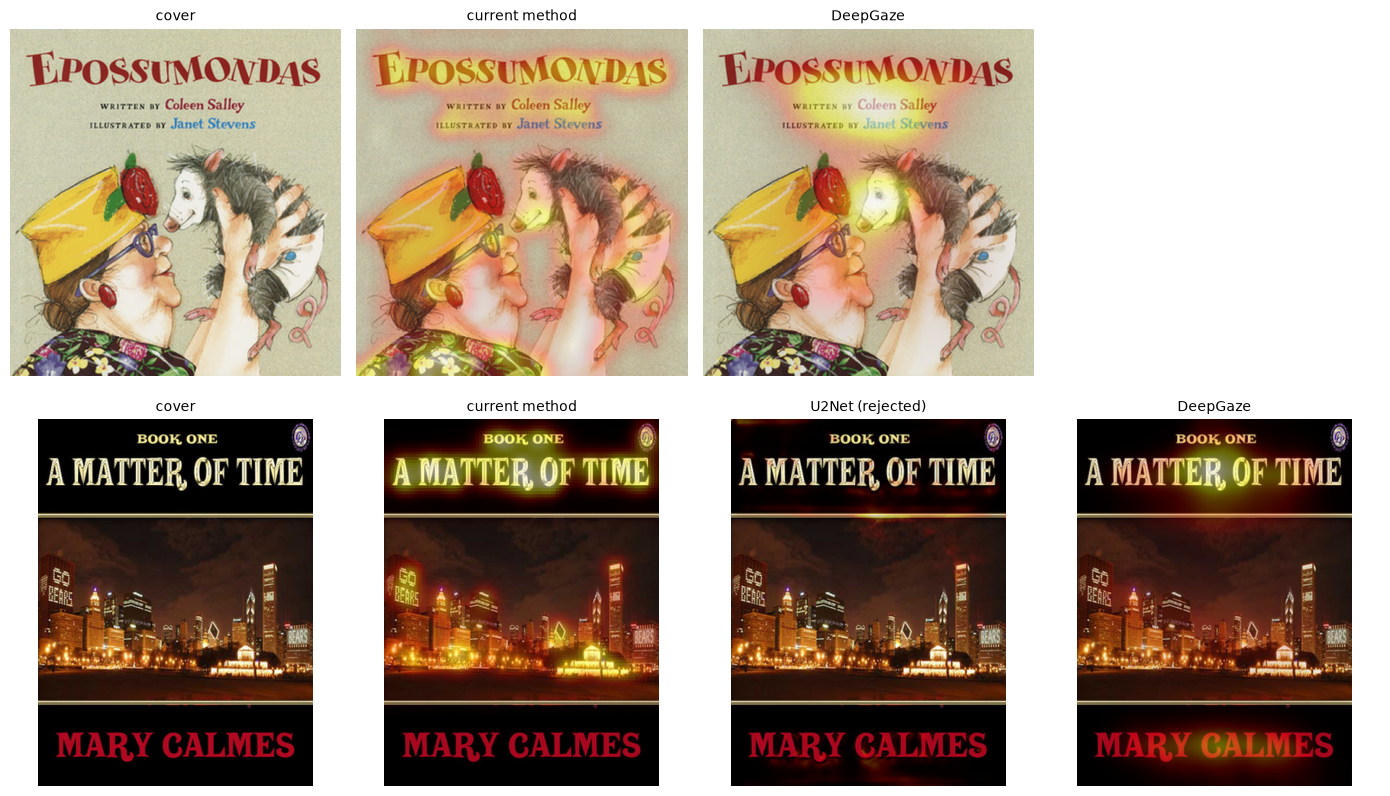

In [3]:
import matplotlib.pyplot as plt
from scripts.analysis.saliency_model_ab import example_figures

figs = example_figures()
rows = [
    ("figurecover", ["plain", "old", "new"], ["cover", "current method", "DeepGaze"]),
    ("textcover", ["plain", "old", "u2net", "new"], ["cover", "current method", "U2Net (rejected)", "DeepGaze"]),
]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for r, (prefix, keys, titles) in enumerate(rows):
    for c in range(4):
        ax = axes[r, c]
        if c < len(keys):
            ax.imshow(figs[f"{prefix}_{keys[c]}"])
            ax.set_title(titles[c], fontsize=10)
        ax.axis("off")
fig.tight_layout()

## 2. Does the fame confound actually leak without leave-one-out?

The fix (LOO) was built correctly from the start, which means the failure case it prevents
was never demonstrated — until now.

In [4]:
import subprocess
print(subprocess.run([sys.executable, '-m', 'scripts.analysis.author_fame_leakage'],
                      capture_output=True, text=True).stdout)

n = 42345 books, 18352 authors

spearman(fame proxy, its own outcome) -- naive (leaky) vs leave-one-out:

  sum_ratings  vs numRatings :  naive +0.794   ->   LOO +0.574
  mean_rating  vs rating    :  naive +0.774   ->   LOO +0.628

the starkest case -- solo authors (12158 books, 28.7% of the set):
  for a solo author, naive sum_ratings IS this book's numRatings, exactly.
  spearman(naive_sum, numRatings) among solo authors = +1.0000  (perfect, by construction)
  LOO_sum among solo authors = 0 for all 12158 of them, exactly, by construction (no other book to sum) -- correlation is undefined on a constant, which is the point: LOO correctly contributes zero fame signal for these books instead of smuggling in the answer.

what this means for Model A: a naive fame covariate would have let the model partly
'predict' numRatings using numRatings itself for the 28.7% of books whose author has
no other book in the set -- inflating Model A's apparent explanatory power, which would
then understate

## 3. Thumbnail legibility, v1 vs v2, on a real cover

In [5]:
from scripts.analysis.thumbnail_legibility_ab import main as thumbnail_legibility_ab
thumbnail_legibility_ab()

n = 50 sample covers (46 with any OCR text)

  v1 char-retention == 0 exactly : 12 / 46
  v2 box-retention  == 0 exactly : 3 / 50

  correlation with title contrast (a real legibility signal should be positive):
    spearman(v1_char_retention, title_contrast) = -0.035
    spearman(v2_box_retention,  title_contrast) = +0.141

  spearman(v1, v2) = +0.293

                                                                 chars_full  v1_char_retention  v2_box_retention  title_contrast
key                                                                                                                             
1024240.Isle_of_Destiny.jpg                                              27              0.481             0.750           3.045
10506860-the-interludes.jpg                                              38              0.000             0.500           4.080
11334433-confessions-of-a-d-list-supervillain.jpg                        28              0.143             0.500           6.221

full-res (480px) OCR read: ['Green Ange l', 'ALICE', 'HOFFMAN']
v1 @ 160px read: (nothing)
v2 @ 160px: 2 text regions detected


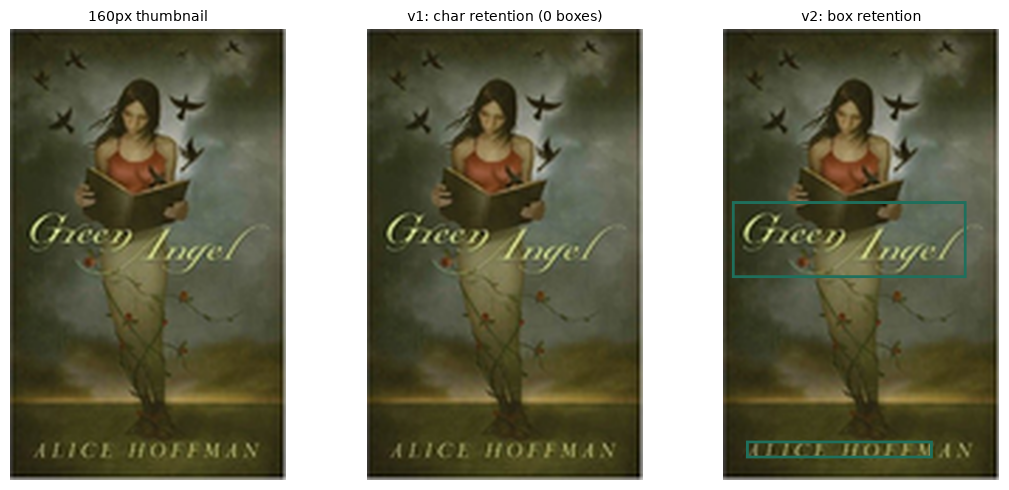

In [6]:
from scripts.analysis.thumbnail_legibility_ab import example_figure

ex = example_figure()
fig, axes = plt.subplots(1, 3, figsize=(11, 5))
for ax, k, title in zip(axes, ["plain", "v1", "v2"],
                         ["160px thumbnail", "v1: char retention (0 boxes)", "v2: box retention"]):
    ax.imshow(ex[k]); ax.set_title(title, fontsize=10); ax.axis("off")
fig.tight_layout()
print("full-res (480px) OCR read:", ex["full_text"])
print("v1 @ 160px read:", ex["v1_text"] or "(nothing)")
print(f"v2 @ 160px: {ex['v2_count']} text regions detected")

## 4. EasyOCR vs. Tesseract — was the original claim actually true?

Needs `pytesseract` (requirements-dev.txt) and the `tesseract` binary (`brew install tesseract`).

In [7]:
from scripts.analysis.ocr_engine_ab import main as ocr_engine_ab
ocr_engine_ab()

n=150

               min   50%    max  mean
easyocr_chars  0.0  34.0  124.0  37.5
tess_3         0.0  14.0  134.0  20.5
tess_11        0.0  30.0  171.0  35.8
tess_12        0.0  31.5  171.0  34.5

EasyOCR found 0 chars on 4/150 covers

  PSM 3: of the 146 covers where EasyOCR found text, Tesseract found 0 on 47 (32.2%); median chars tesseract=14 vs easyocr=36
  PSM 11: of the 146 covers where EasyOCR found text, Tesseract found 0 on 2 (1.4%); median chars tesseract=30 vs easyocr=36
  PSM 12: of the 146 covers where EasyOCR found text, Tesseract found 0 on 2 (1.4%); median chars tesseract=32 vs easyocr=36

--- Green Angel: cursive title 'Green Angel' + small-caps 'ALICE HOFFMAN' ---
(raw char *count* above says tesseract is competitive with the right PSM; this
 checks whether what it reads is actually right, which the count can't tell you)
  PSM 3 (default (3)): 12 chars -> 'ALICE HOFFMAN'


  PSM 11 (sparse text (11)): 23 chars -> 'a /  / >> /  / hn /  / Gave. /  / L) /  / = /  / A /  / : /  / : /  / — os /  / ALICE HOFFMAN'
  PSM 12 (sparse text + osd (12)): 23 chars -> 'a /  / >> /  / hn /  / Gave. /  / L) /  / = /  / A /  / : /  / : /  / — os /  / ALICE HOFFMAN'
  EasyOCR: 'Green Ange l', 'ALICE', 'HOFFMAN' -> 15 chars (title garbled but legible, author exact)
